Implement logistic regression(X, y, lr=0.01, max iter=1000, tol=1e-5) from scratch
in Python (do NOT use external libraries like sklearn.linear model).
Algorithm steps:

• Initialize the weight vector w ∈ R
d
and bias b ∈ R to zeros or small random numbers.

• Compute the predicted probabilities using the sigmoid function:
yˆ = σ(Xw + b) =
1
1 + e
−(Xw+b)

• Update weights and bias using gradient descent based on the binary cross-entropy loss.

• Stop when the change in the loss function between consecutive iterations is less than tol or
max iter is reached.

• Return the final weights, bias, and a list of the loss values over the iterations.

Test the function on a 2-D synthetic dataset (sklearn.datasets.make classification, 2 classes,
300 points, n features=2, n redundant=0) and plot:

• The data points colored by their true class labels.

• The linear decision boundary learned by your model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)

    return -np.mean(
        y_true*np.log(y_pred)
        + (1-y_true)*np.log(1-y_pred)
    )

def logistic_regression(X, y,
                        lr=0.01,
                        max_iter=1000,
                        tol=1e-5):

    n_samples, n_features = X.shape

    w = np.zeros(n_features)
    b = 0

    losses = []

    prev_loss = float("inf")

    for i in range(max_iter):

        linear = np.dot(X, w) + b
        y_hat = sigmoid(linear)

        loss = binary_cross_entropy(y, y_hat)

        losses.append(loss)

        if abs(prev_loss - loss) < tol:
            break

        prev_loss = loss

        dw = (1/n_samples) * np.dot(X.T, (y_hat - y))
        db = (1/n_samples) * np.sum(y_hat - y)

        w -= lr * dw
        b -= lr * db

    return w, b, losses

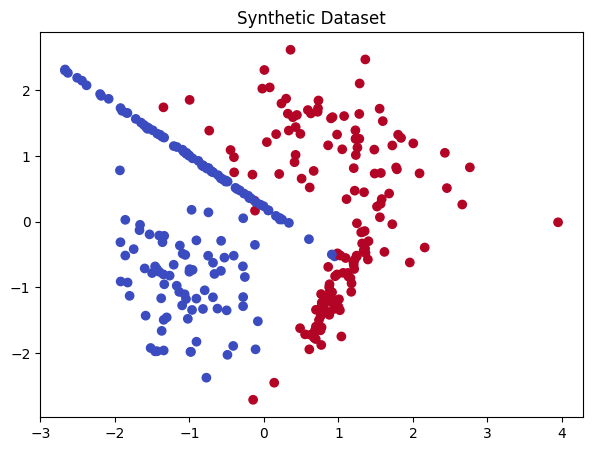

In [3]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_classes=2,
    random_state=42
)

w, b, losses = logistic_regression(X, y, lr=0.1)

plt.figure(figsize=(7,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
plt.title("Synthetic Dataset")
plt.show()

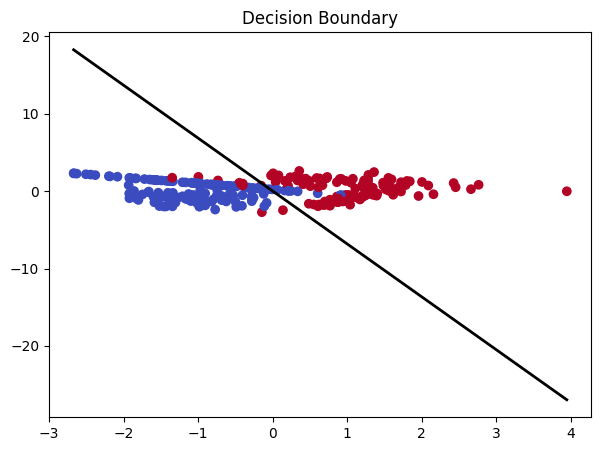

In [4]:
plt.figure(figsize=(7,5))

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap='coolwarm'
)

x1 = np.linspace(X[:,0].min(), X[:,0].max(), 100)

x2 = -(w[0]*x1 + b)/w[1]

plt.plot(x1, x2, color='black', linewidth=2)

plt.title("Decision Boundary")
plt.show()

Apply your logistic regression() implementation to an image classification task.
Steps:

• Load the Digits dataset (sklearn.datasets.load digits()) and filter it to keep only two
classes (e.g., digits ‘0’ and ‘1’) for binary classification.

• Flatten the 8 × 8 images into 1-D arrays of 64 features.

• Split the dataset into an 80% training set and a 20% test set.

• Train your model on the training set and generate predictions for the test set.

• Report the runtime of your training loop and the final classification accuracy on the test set.

• Display a 2 × 2 grid of randomly selected test images side-by-side with their “Predicted” and
“True” labels in the title.

In [5]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [6]:
digits = load_digits()

mask = (digits.target == 0) | (digits.target == 1)

X = digits.data[mask]
y = digits.target[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
start = time.time()

w, b, losses = logistic_regression(
    X_train,
    y_train,
    lr=0.01,
    max_iter=1000
)

runtime = time.time() - start

print("Training Time:", runtime)

Training Time: 0.04001045227050781


In [8]:
def predict(X, w, b, threshold=0.5):
    probs = sigmoid(np.dot(X, w) + b)
    return (probs >= threshold).astype(int)

y_pred = predict(X_test, w, b)

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

Accuracy: 1.0


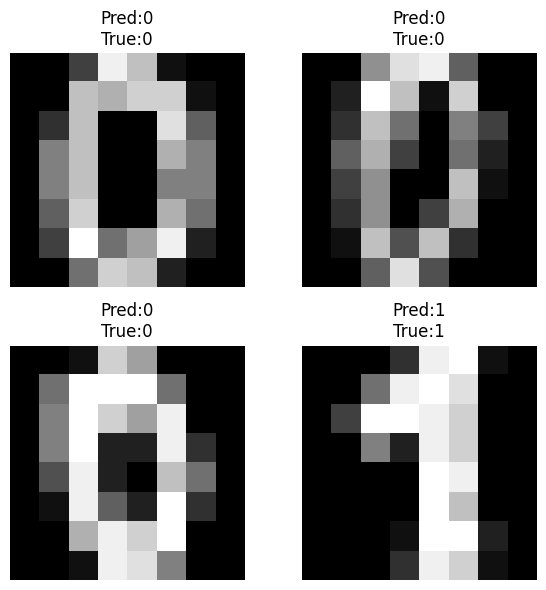

In [9]:
indices = np.random.choice(
    len(X_test),
    4,
    replace=False
)

fig, axes = plt.subplots(2,2, figsize=(6,6))

for ax, idx in zip(axes.ravel(), indices):

    image = X_test[idx].reshape(8,8)

    ax.imshow(image, cmap='gray')

    ax.set_title(
        f"Pred:{y_pred[idx]}\nTrue:{y_test[idx]}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

Investigate the effect of the learning rate lr on model convergence. For a fixed dataset (make classification
with 2 classes, 500 points):

• Run your Logistic Regression for lr = 0.001, 0.01, 0.1, 1.0.

• For each, report:
– Final binary cross-entropy loss value.
– Number of iterations completed.

• Plot the Loss (y-axis) vs. Iteration Number (x-axis) for all four learning rates on a single plot
(using different colors/labels).

• Write a short analysis: how does increasing lr affect the speed of convergence and the stability
of the loss curve?

In [24]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_classes=2,
    random_state=42
)

lr=0.001 | Final Loss= 0.510369597747367 | Iterations= 1000
lr=0.01 | Final Loss= 0.3057148239136519 | Iterations= 1000
lr=0.1 | Final Loss= 0.28137379840784515 | Iterations= 391
lr=1.0 | Final Loss= 0.2803502592879787 | Iterations= 66


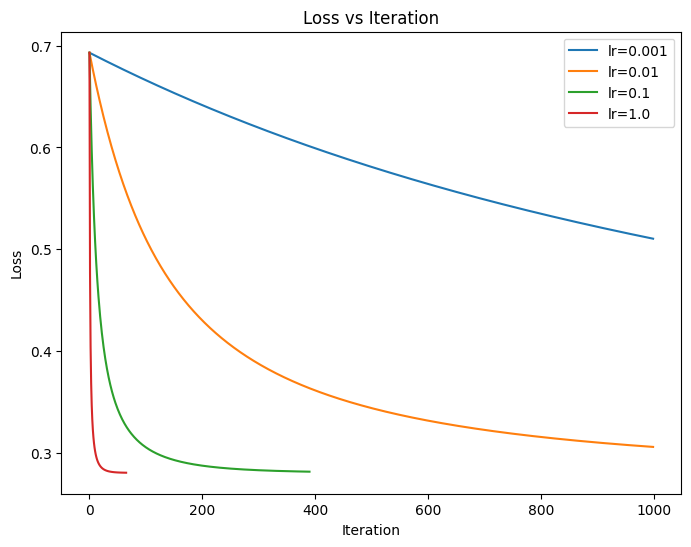

In [25]:
learning_rates = [0.001, 0.01, 0.1, 1.0]

results = {}

plt.figure(figsize=(8,6))

for lr in learning_rates:

    w, b, losses = logistic_regression(
        X,
        y,
        lr=lr,
        max_iter=1000
    )

    results[lr] = losses

    plt.plot(
        losses,
        label=f"lr={lr}"
    )

    print(
        f"lr={lr}",
        "| Final Loss=",
        losses[-1],
        "| Iterations=",
        len(losses)
    )

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss vs Iteration")
plt.show()

Analysis :

1. Small learning rates converge slowly.
2. Moderate learning rates converge faster.
3. Very large learning rates may oscillate.
4. lr=0.1 usually provides a good balance between speed and stability.




Use Precision, Recall, and F1-Score as validity indices for skewed data.
Implement from scratch:

• precision(y true, y pred) =
T P
T P+FP

• recall(y true, y pred) =
T P
T P+FN

• f1 score(y true, y pred) = 2 ×
Precision×Recall
Precision+Recall
Steps:

• Load the Breast Cancer dataset (sklearn.datasets.load breast cancer()). Train your
model on an 80% split.

• Instead of using the default 0.5 probability threshold for classification, generate predictions for
classification thresholds t ∈ {0.1, 0.2, . . . , 0.9}. (i.e., if ˆy ≥ t, class 1, else class 0).

• Plot Precision and Recall vs. the threshold t on a single plot (one curve will generally increase,
one will decrease).

• Select and report the best threshold t based on the intersection of the two curves or the highest
F1-score.

In [10]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [11]:
def precision(y_true, y_pred):

    TP = np.sum((y_true==1)&(y_pred==1))
    FP = np.sum((y_true==0)&(y_pred==1))

    return TP/(TP+FP+1e-15)

def recall(y_true, y_pred):

    TP = np.sum((y_true==1)&(y_pred==1))
    FN = np.sum((y_true==1)&(y_pred==0))

    return TP/(TP+FN+1e-15)

def f1_score_custom(y_true, y_pred):

    p = precision(y_true,y_pred)
    r = recall(y_true,y_pred)

    return 2*p*r/(p+r+1e-15)

In [12]:
data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

w, b, losses = logistic_regression(
    X_train,
    y_train,
    lr=0.001,
    max_iter=3000
)

In [13]:
probs = sigmoid(np.dot(X_test,w)+b)

thresholds = np.arange(0.1,1.0,0.1)

precisions = []
recalls = []
f1s = []

for t in thresholds:

    preds = (probs >= t).astype(int)

    p = precision(y_test,preds)
    r = recall(y_test,preds)
    f1 = f1_score_custom(y_test,preds)

    precisions.append(p)
    recalls.append(r)
    f1s.append(f1)

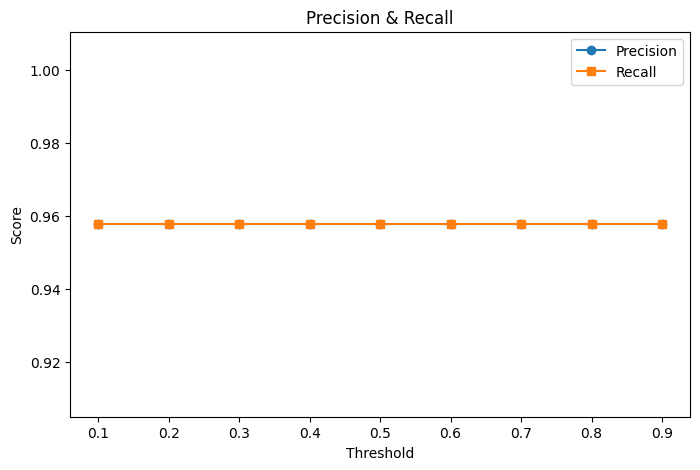

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    precisions,
    marker='o',
    label='Precision'
)

plt.plot(
    thresholds,
    recalls,
    marker='s',
    label='Recall'
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Precision & Recall")
plt.show()

In [15]:
best_idx = np.argmax(f1s)

print("Best Threshold =", thresholds[best_idx])
print("Best F1 Score =", f1s[best_idx])

Best Threshold = 0.1
Best F1 Score = 0.9577464788732388


Perform document classification with Logistic Regression using TF-IDF vectors.
Steps:

• Load up to 2,000 documents from sklearn.datasets.fetch 20newsgroups selecting exactly two contrasting categories (e.g., “rec.autos” and “sci.space”) to create a binary classification problem.

• Compute TF-IDF vectors (TfidfVectorizer with max features=500 to keep training time
reasonable).

• Split into Train/Test sets and run your custom Logistic Regression model.

• Compare your predictions against the true categories on the test set and report the Accuracy and F1-Score.

• Interpretability: Find the features (words) associated with the 5 highest positive weights and
the 5 most negative weights in your learned weight vector w. Display these words in a bar chart
to show which words drive the model’s decisions for each class.

In [16]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [17]:
categories = [
    "rec.autos",
    "sci.space"
]

data = fetch_20newsgroups(
    categories=categories,
    remove=('headers','footers','quotes')
)

texts = data.data
y = data.target

In [18]:
vectorizer = TfidfVectorizer(
    max_features=500,
    stop_words='english'
)

X = vectorizer.fit_transform(texts)

X = X.toarray()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
w, b, losses = logistic_regression(
    X_train,
    y_train,
    lr=0.1,
    max_iter=1000
)

In [21]:
y_pred = predict(X_test,w,b)

accuracy = np.mean(y_pred == y_test)

print("Accuracy =", accuracy)

f1 = f1_score_custom(y_test,y_pred)

print("F1 Score =", f1)

Accuracy = 0.8865546218487395
F1 Score = 0.8831168831168825


In [22]:
feature_names = vectorizer.get_feature_names_out()

top_positive = np.argsort(w)[-5:]
top_negative = np.argsort(w)[:5]

positive_words = feature_names[top_positive]
negative_words = feature_names[top_negative]

positive_weights = w[top_positive]
negative_weights = w[top_negative]

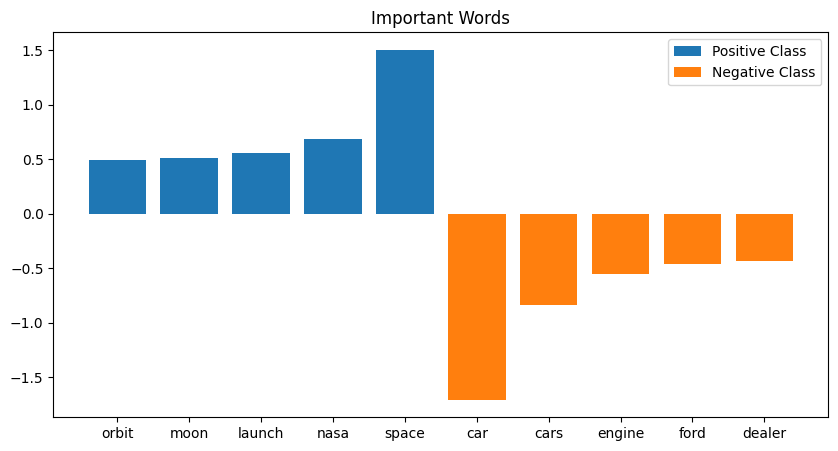

In [23]:
plt.figure(figsize=(10,5))

plt.bar(
    positive_words,
    positive_weights,
    label="Positive Class"
)

plt.bar(
    negative_words,
    negative_weights,
    label="Negative Class"
)

plt.title("Important Words")
plt.legend()
plt.show()